# Import Libraries
Import necessary libraries including pandas, numpy, matplotlib, seaborn, cmdstanpy, and arviz to support data manipulation, statistical modeling, and visualization.

In [2]:
# Import Libraries
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import cmdstanpy
from cmdstanpy import CmdStanModel
import arviz as az

# Set plotting style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')

sns.set_theme(font_scale=1.2, rc={'axes.titlesize': plt.rcParams['font.size'] * 1.5})
np.random.seed(42)  # For reproducibility

In [3]:
import matplotlib as mpl

# Set all text elements to pure black
mpl.rcParams['text.color'] = 'black'
mpl.rcParams['axes.labelcolor'] = 'black'
mpl.rcParams['xtick.color'] = 'black'
mpl.rcParams['ytick.color'] = 'black'
mpl.rcParams['axes.titlecolor'] = 'black'

mpl.rcParams['text.color'] = '.05'
mpl.rcParams['axes.labelcolor'] = '.05'
mpl.rcParams['xtick.color'] = '.05'
mpl.rcParams['ytick.color'] = '.05'
mpl.rcParams['axes.titlecolor'] = '.05'

# Load and Preprocess Data
Load the normalized weekly data and socioeconomic data. Prepare the data for modeling by handling missing values, data transformations, and merging datasets at appropriate time scales.

In [4]:
# Load and Preprocess Data

# Define project paths
PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT", "."))
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "data" / "analysis"

# Create output directory if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load raw data
print("Loading raw data...")
incidents_df = pd.read_csv(DATA_DIR / 'processed/incidents.csv')
weather_df = pd.read_csv(DATA_DIR / 'processed/weather_daily.csv')
socio_df = pd.read_csv(DATA_DIR / 'analysis/normalized_socioeconomic_country.csv')

# Convert datetime columns to datetime format
incidents_df['datetime'] = pd.to_datetime(incidents_df['datetime'])
weather_df['date'] = pd.to_datetime(weather_df['date'])

# Add week information to incidents data
print("Processing incident data...")
incidents_df['year'] = incidents_df['datetime'].dt.year
incidents_df['week'] = incidents_df['datetime'].dt.isocalendar().week
incidents_df['year_week'] = incidents_df['year'].astype(str) + '-' + incidents_df['week'].astype(str).str.zfill(2)

# Add week information to weather data
print("Processing weather data...")
weather_df['year'] = weather_df['date'].dt.year
weather_df['week'] = weather_df['date'].dt.isocalendar().week
weather_df['year_week'] = weather_df['year'].astype(str) + '-' + weather_df['week'].astype(str).str.zfill(2)

# Aggregate incidents by week for the whole country
incidents_weekly = incidents_df.groupby(['year_week', 'year', 'week']).size().reset_index(name='incidents')

# Aggregate weather data by week for the whole country
weather_weekly = weather_df.groupby(['year_week', 'year', 'week']).agg({
    'temperature': 'mean',
    'humidity': 'mean',
    'precipation': 'sum'
}).reset_index()

# Rename weather columns for clarity
weather_weekly = weather_weekly.rename(columns={
    'temperature': 'mean_temperature',
    'humidity': 'mean_humidity',
    'precipation': 'total_precipitation'
})

# Merge incidents and weather data
print("Merging datasets...")
df_country_weekly = pd.merge(
    incidents_weekly,
    weather_weekly,
    on=['year_week', 'year', 'week'],
    how='left'
)

socio_columns = ['population_density', 'road_density', 'passenger_cars']
socio_yearly = socio_df[socio_columns + ['year']]

# Merge socioeconomic data with the weekly data
df_country_weekly = pd.merge(
    df_country_weekly,
    socio_yearly,
    on='year',
    how='left'
)

# Create a date column for plotting
df_country_weekly['date'] = pd.to_datetime(df_country_weekly['year_week'].apply(
    lambda x: f"{x.split('-')[0]}-W{x.split('-')[1]}-1"
), format='%Y-W%W-%w')

# Sort by date
df_country_weekly = df_country_weekly.sort_values('date')

# Check for missing values
missing_values = df_country_weekly.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Fill missing values if any
if missing_values.sum() > 0:
    print("Filling missing values with appropriate methods...")
    df_country_weekly = df_country_weekly.fillna(method='ffill')

# Check data after filling
print("Remaining missing values:\n", df_country_weekly.isnull().sum())

# Create a normalized version of the dataset
print("Normalizing data...")
df_normalized = df_country_weekly.copy()

# Standardize weather parameters (except precipitation)
weather_params = ['mean_temperature', 'mean_humidity']
df_normalized[weather_params] = df_normalized[weather_params].apply(lambda x: (x - x.mean()) / x.std())

# Apply log transformation to precipitation (commonly right-skewed)
df_normalized['total_precipitation'] = np.log1p(df_normalized['total_precipitation'])

# Apply log transformation to socioeconomic variables with skewed distributions
# socio_params = ['population_density', 'paved_roads', 'improved_roads', 'total_vehicles', 
#                 'passenger_cars', 'buses', 'trucks', 'semi_trailers', 'road_density', 'road_per_capita']
# df_normalized[socio_params] = df_normalized[socio_params].apply(lambda x: np.log1p(x))

# Save the normalized data to CSV
output_file = OUTPUT_DIR / 'normalized_weekly_data.csv'
print(f"Saving normalized weekly data to {output_file}")
df_normalized.to_csv(output_file, index=False)

print("Normalized weekly data has been successfully created and saved.")
df_weekly = df_normalized

df_weekly = df_weekly[df_weekly['incidents'] != df_weekly['incidents'].nsmallest(1).values[0]] # Significant outlier
df_weekly

Loading raw data...


/tmp/ipykernel_890/570547560.py:13: DtypeWarning: Columns (9,10,11,13,14,15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  incidents_df = pd.read_csv(DATA_DIR / 'processed/incidents.csv')


Processing incident data...
Processing weather data...
Merging datasets...
Missing values in each column:
 year_week              0
year                   0
week                   0
incidents              0
mean_temperature       0
mean_humidity          0
total_precipitation    0
population_density     0
road_density           0
passenger_cars         0
date                   0
dtype: int64
Remaining missing values:
 year_week              0
year                   0
week                   0
incidents              0
mean_temperature       0
mean_humidity          0
total_precipitation    0
population_density     0
road_density           0
passenger_cars         0
date                   0
dtype: int64
Normalizing data...
Saving normalized weekly data to /project/data/analysis/normalized_weekly_data.csv
Normalized weekly data has been successfully created and saved.


,year_week,year,week,incidents,mean_temperature,mean_humidity,total_precipitation,population_density,road_density,passenger_cars,date
0,2020-01,2020,1,280,-1.130634,0.422159,7.430216,1.0,0.0,0.0,2020-01-06
1,2020-02,2020,2,443,-0.877091,1.098838,7.504505,1.0,0.0,0.0,2020-01-13
2,2020-03,2020,3,477,-0.939740,0.840184,5.853118,1.0,0.0,0.0,2020-01-20
3,2020-04,2020,4,429,-1.188621,0.990244,5.927360,1.0,0.0,0.0,2020-01-27
4,2020-05,2020,5,507,-0.677239,0.792343,8.824292,1.0,0.0,0.0,2020-02-03
...,...,...,...,...,...,...,...,...,...,...,...
205,2023-48,2023,48,301,-1.730302,1.343530,8.269893,0.0,1.0,1.0,2023-11-27
206,2023-49,2023,49,272,-1.644101,1.385465,6.860622,0.0,1.0,1.0,2023-12-04
207,2023-50,2023,50,416,-0.831461,1.490682,8.136154,0.0,1.0,1.0,2023-12-11
208,2023-51,2023,51,530,-0.778678,0.563376,9.107827,0.0,1.0,1.0,2023-12-18


In [5]:
df_weekly['incidents'].describe()

count    209.000000
mean     423.574163
std      108.151716
min      194.000000
25%      334.000000
50%      429.000000
75%      509.000000
max      665.000000
Name: incidents, dtype: float64

# Explore Weekly Data and Correlations
Create visualizations showing weekly incident trends, correlations between socioeconomic factors and yearly incident counts, and correlations between weather factors and weekly incident counts. Generate separate barplots for socioeconomic data and yearly incident counts.

<>:39: SyntaxWarning: invalid escape sequence '\_'
<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\_'
<>:39: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_890/1437346491.py:39: SyntaxWarning: invalid escape sequence '\_'
  plt.title(f"Distribution of $\mathit{{{predictor.replace('_', '\_')}}}$", fontsize=18)
/tmp/ipykernel_890/1437346491.py:39: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f"Distribution of $\mathit{{{predictor.replace('_', '\_')}}}$", fontsize=18)


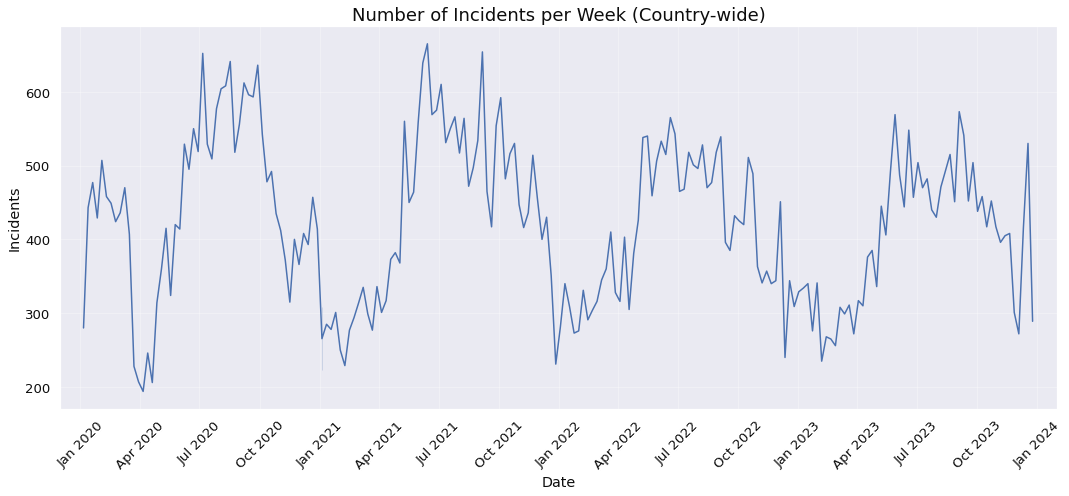

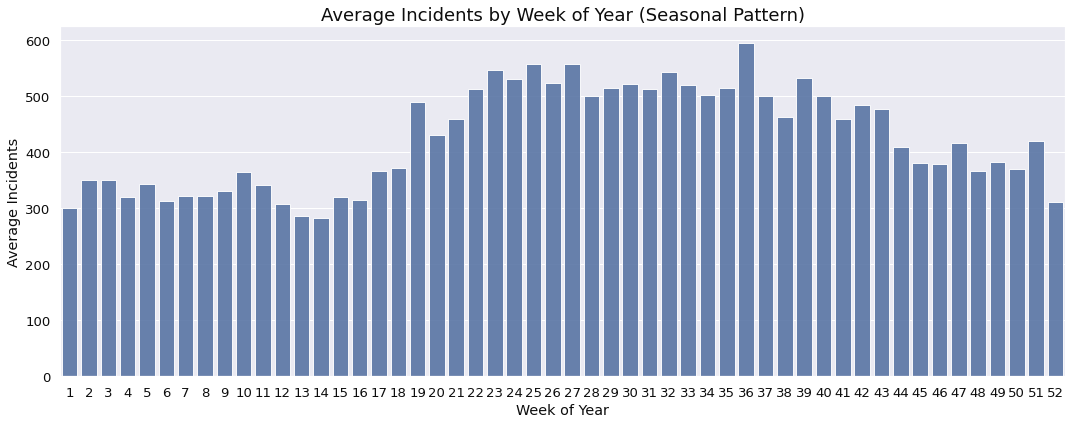

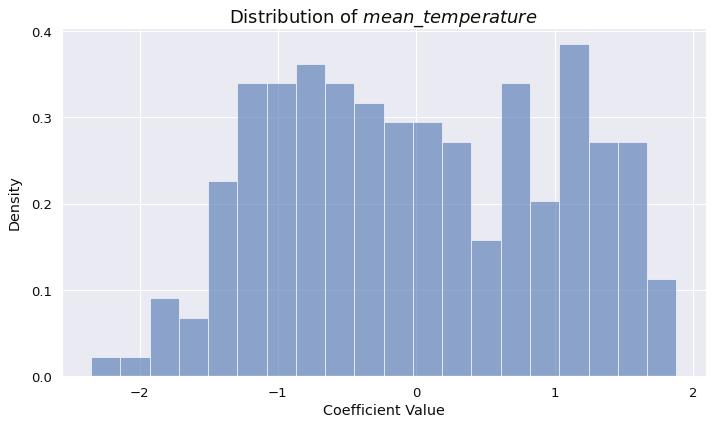

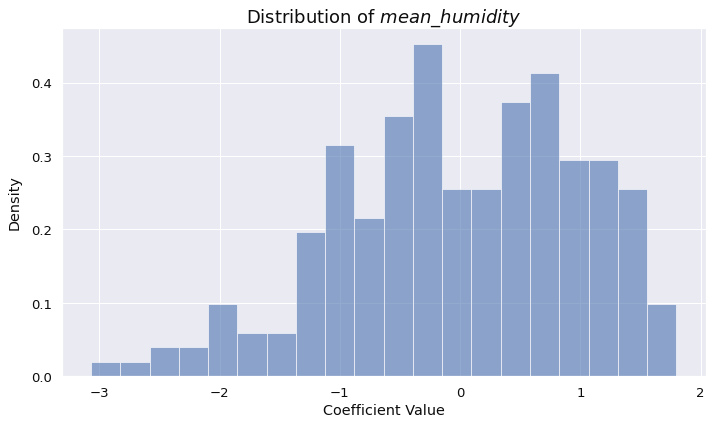

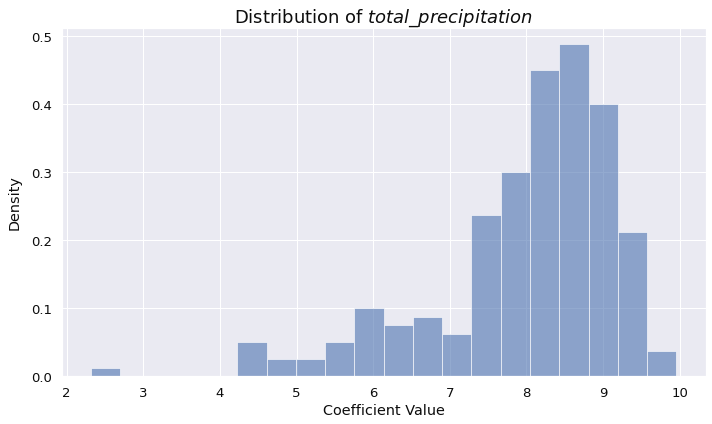

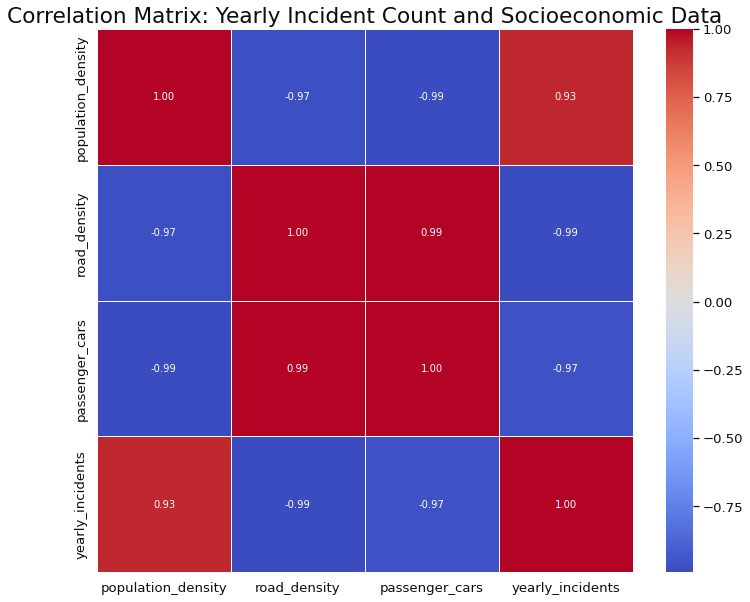

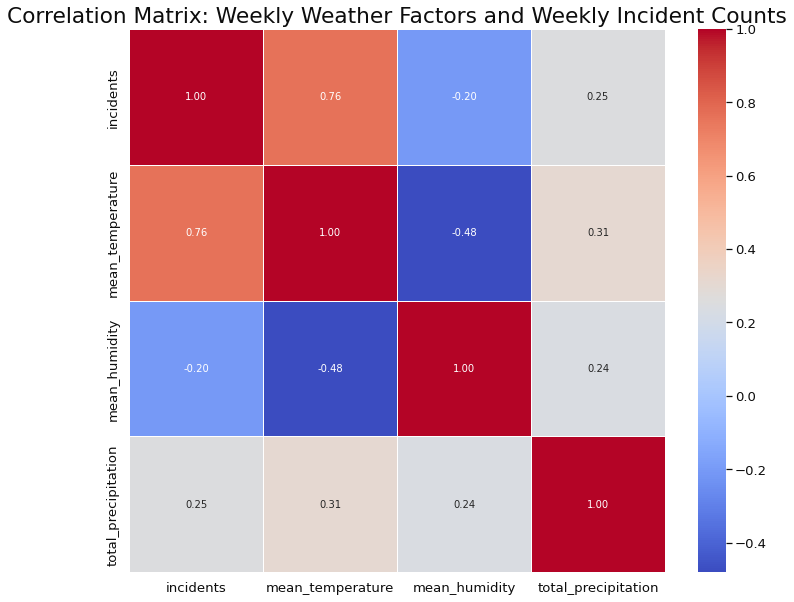

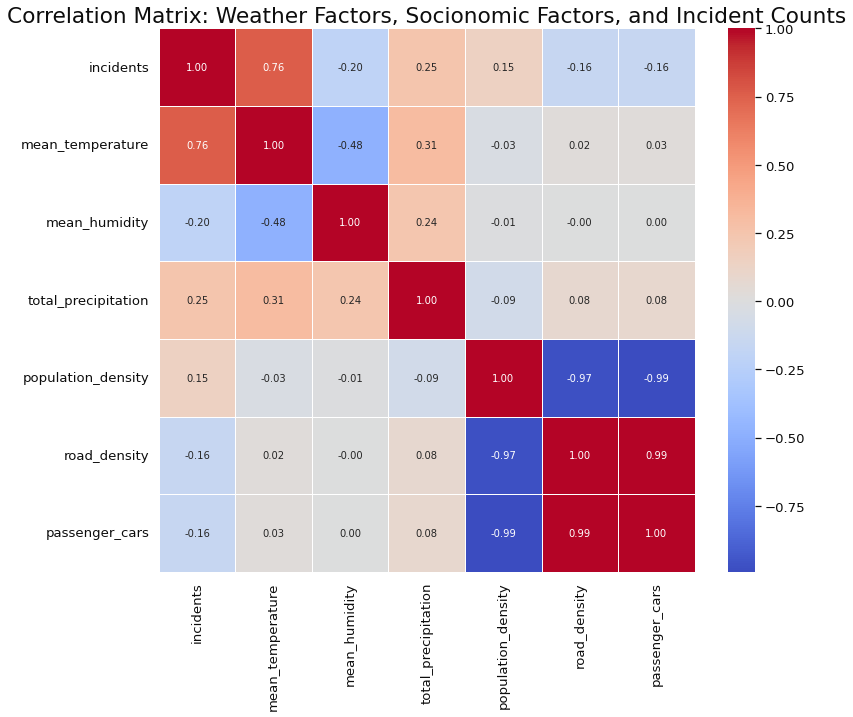

In [6]:
import datetime as dt
from matplotlib.dates import MonthLocator, DateFormatter
from matplotlib.ticker import FormatStrFormatter, MultipleLocator

# Time series plot of incidents over time
plt.figure(figsize=(15, 7))
sns.lineplot(x='date', y='incidents', data=df_weekly)
plt.title('Number of Incidents per Week (Country-wide)', fontsize=18)
plt.xlabel('Date')
plt.ylabel('Incidents')

# Set explicit date range from Jan 2020 to Dec 2023
plt.xlim([dt.datetime(2019, 12, 1), dt.datetime(2024, 1, 31)])

# Format x-axis to show month names
plt.gca().xaxis.set_major_locator(MonthLocator(interval=3))  # Show every 3 months
plt.gca().xaxis.set_major_formatter(DateFormatter('%b %Y'))  # Format as 'Jan 2020'
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



plt.figure(figsize=(15, 6))
weekly_by_week = df_weekly.groupby('week')['incidents'].mean().reset_index().take(range(0, 52))
sns.barplot(x='week', y='incidents', data=weekly_by_week, alpha=0.9)
plt.title('Average Incidents by Week of Year (Seasonal Pattern)', fontsize=18)
plt.xlabel('Week of Year')
plt.ylabel('Average Incidents')
# plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


for i, predictor in enumerate(['mean_temperature', 'mean_humidity', 'total_precipitation']):
    plt.figure(figsize=(10, 6))
    plt.hist(df_weekly[predictor], bins=20, alpha=0.6, density=True)
    plt.title(f"Distribution of $\mathit{{{predictor.replace('_', '\_')}}}$", fontsize=18)
    plt.xlabel('Coefficient Value')
    plt.ylabel('Density', labelpad=10)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # Format to 1 decimal place
    plt.gca().yaxis.set_major_locator(MultipleLocator(0.1))  # Set minimum tick spacing to 0.5
    plt.tight_layout()
    plt.show()



# Correlation matrix between yearly incident count and yearly socioeconomic data
yearly_incidents = incidents_df.groupby('year').size().reset_index(name='yearly_incidents')
socio_yearly_incidents = pd.merge(socio_yearly, yearly_incidents, on='year')
plt.figure(figsize=(12, 10))
sns.heatmap(socio_yearly_incidents.drop(columns=['year']).corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Yearly Incident Count and Socioeconomic Data')
plt.show()

# Correlation matrix between weekly weather factors and weekly incident counts
plt.figure(figsize=(12, 10))
sns.heatmap(df_weekly[['incidents', 'mean_temperature', 'mean_humidity', 'total_precipitation']].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Weekly Weather Factors and Weekly Incident Counts')
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(df_weekly[['incidents', 'mean_temperature', 'mean_humidity', 'total_precipitation', *socio_columns]].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Weather Factors, Socionomic Factors, and Incident Counts')
plt.show()

# Barplots of socioeconomic data and yearly incident counts
# for col in socio_columns:
#     plt.figure(figsize=(12, 6))
#     sns.barplot(x='year', y=col, data=socio_yearly_incidents)
#     plt.title(f'{col.replace("_", " ").title()} by Year')
#     plt.xlabel('Year')
#     plt.ylabel(col.replace("_", " ").title())
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

# plt.figure(figsize=(12, 6))
# sns.barplot(x='year', y='yearly_incidents', data=socio_yearly_incidents)
# plt.title('Yearly Incident Counts')
# plt.xlabel('Year')
# plt.ylabel('Yearly Incidents')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# Model 1: Weather Factors Only
Define the first model using only weather factors as predictors. Prepare the data structure for Stan with appropriate priors based on domain knowledge.

In [7]:
# Model 1: Socioeconomic Factors Only

# Prepare the data structure for Stan
predictors_weather = ['mean_temperature', 'mean_humidity', 'total_precipitation']
X_socio = df_weekly[predictors_weather].values

# Define Stan data
stan_data_weather = {
    'N': len(df_weekly),
    'K': len(predictors_weather),
    'X': X_socio,
    'y': df_weekly['incidents'].values,
    'alpha_mean': 3.0,        # Prior for intercept, exp(3) ≈ 20 weekly incidents
    'alpha_sd': 0.3,          # Reasonable variation for weekly data
    'beta_sd': 0.2,           # Prior for coefficients
    'max_log_lambda': 6.7     # log(1800) ≈ 7.5, caps lambda at ~1800 weekly incidents
}

# Display the prepared data dimensions
print(f"Number of observations (N): {stan_data_weather['N']}")
print(f"Number of predictors (K): {stan_data_weather['K']}")

Number of observations (N): 209
Number of predictors (K): 3


# Prior Analysis for Model 1
Sample from prior distributions for the socioeconomic-only model. Create separate figures for each coefficient and intercept prior distribution, removing legends.

In [8]:
# Prior Analysis for Model 1

# Compile the prior model
prior_model_weather = CmdStanModel(stan_file="models/socioeconomic_prior.stan")

# Sample from prior
prior_fit_weather = prior_model_weather.sample(
    data=stan_data_weather,
    iter_sampling=2000,
    iter_warmup=500,
    chains=4,
    fixed_param=True,
    seed=42,
    output_dir='./models_outputs'
)

# Extract prior samples
alpha_prior_weather = prior_fit_weather.stan_variable("alpha")
beta_prior_weather = prior_fit_weather.stan_variable("beta")
y_prior_weather = prior_fit_weather.stan_variable("y_prior")

INFO:cmdstanpy:found newer exe file, not recompiling
INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status




chain 1 |█▍        | 00:00 Iteration:  200 / 2000 [ 10%]  (Sampling)



chain 1 |██▉       | 00:00 Iteration:  600 / 2000 [ 30%]  (Sampling)


chain 1 |████▍     | 00:00 Iteration: 1000 / 2000 [ 50%]  (Sampling)


chain 1 |█████▉    | 00:00 Iteration: 1400 / 2000 [ 70%]  (Sampling)
chain 1 |███████   | 00:00 Iteration: 1700 / 2000 [ 85%]  (Sampling)

chain 1 |██████████| 00:00 Sampling completed                       
chain 2 |██████████| 00:00 Sampling completed                       
chain 3 |██████████| 00:00 Sampling completed                       
chain 4 |██████████| 00:00 Sampling completed                       


INFO:cmdstanpy:CmdStan done processing.


<>:30: SyntaxWarning: invalid escape sequence '\_'
<>:30: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_890/4290010082.py:30: SyntaxWarning: invalid escape sequence '\_'
  plt.title(f'Prior Distribution of the $\\mathit{{{predictor.replace('_', '\_')}}}$ Coefficient ($\\beta_{{{i+1}}}$)', fontsize=18)


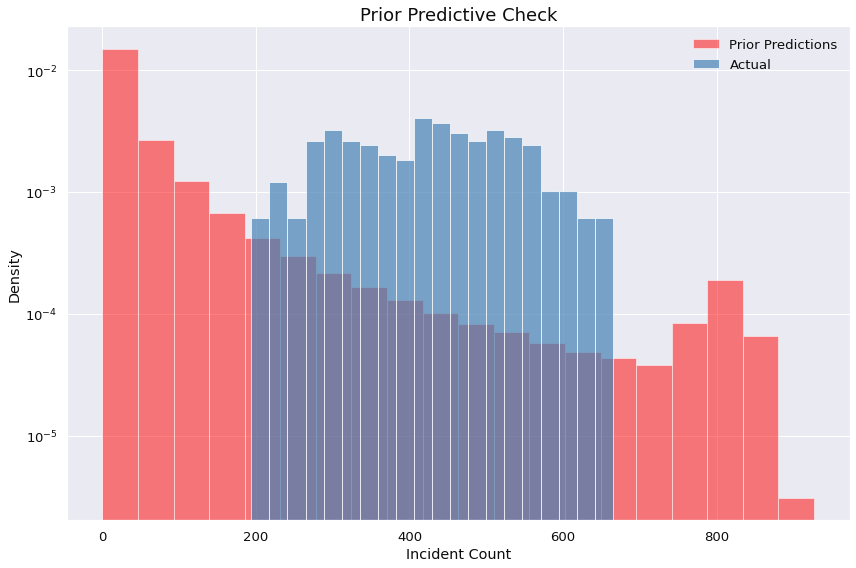

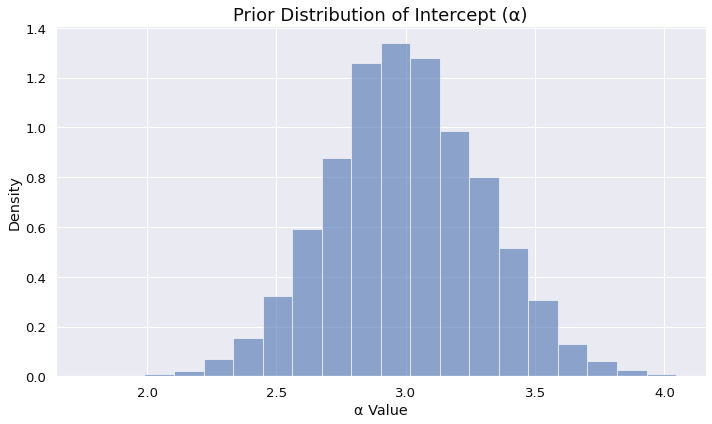

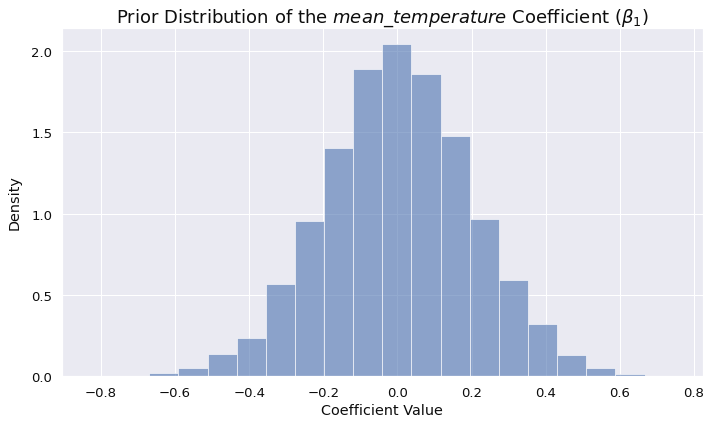

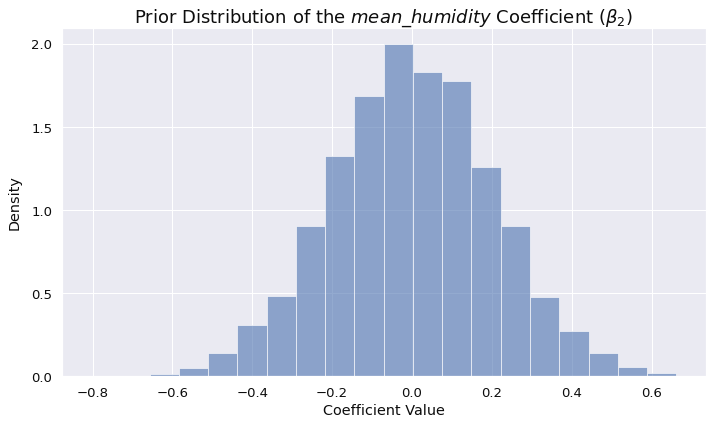

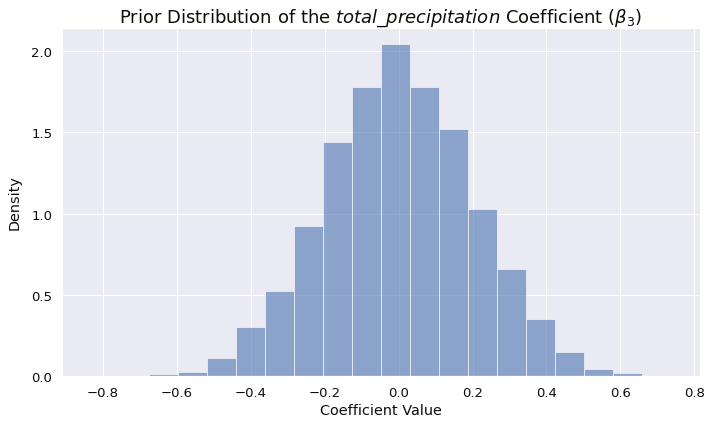

In [9]:
# Prior Predictive Check
plt.figure(figsize=(12, 8))
y_prior_flat_socio_weather = y_prior_weather.flatten()
valid_indices_socio_weather = ~np.isnan(y_prior_flat_socio_weather)
plt.hist(y_prior_flat_socio_weather[valid_indices_socio_weather], bins=20, alpha=0.5, color='red', label='Prior Predictions', density=True)
plt.hist(df_weekly['incidents'], bins=20, alpha=0.7, color='steelblue', label='Actual', density=True)
plt.yscale('log')
plt.title('Prior Predictive Check', fontsize=18)
plt.xlabel('Incident Count')
plt.ylabel('Density')
# plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # Format to 1 decimal place
plt.legend()
plt.tight_layout()
plt.show()

# Prior distribution of intercept
plt.figure(figsize=(10, 6))
plt.hist(alpha_prior_weather, bins=20, alpha=0.6, density=True)
plt.title('Prior Distribution of Intercept (α)', fontsize=18)
plt.xlabel('α Value')
plt.ylabel('Density')
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # Format to 1 decimal place
plt.tight_layout()
plt.show()

# Prior distribution of socioeconomic + weather coefficients
for i, predictor in enumerate(predictors_weather):
    plt.figure(figsize=(10, 6))
    plt.hist(beta_prior_weather[:, i], bins=20, alpha=0.6, density=True)
    plt.title(f'Prior Distribution of the $\\mathit{{{predictor.replace('_', '\_')}}}$ Coefficient ($\\beta_{{{i+1}}}$)', fontsize=18)
    plt.xlabel('Coefficient Value')
    plt.ylabel('Density', labelpad=10)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # Format to 1 decimal place
    plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))  # Set minimum tick spacing to 0.5
    plt.tight_layout()
    plt.show()

# Posterior Analysis for Model 1
Fit the weather model using Stan and analyze posterior distributions. Create trace plots as separate figures, and posterior density plots for each coefficient/intercept as separate figures without prior mean references.

In [10]:
# Posterior Analysis for Model 1

# Compile the posterior model
posterior_model_weather = CmdStanModel(stan_file="models/socioeconomic_posterior.stan")

# Sample from the posterior
posterior_fit_weather = posterior_model_weather.sample(
    data=stan_data_weather,
    iter_sampling=2000,
    iter_warmup=500,
    chains=4,
    seed=42,
    output_dir='./models_outputs'
)

# Extract posterior samples
alpha_post_weather = posterior_fit_weather.stan_variable("alpha")
beta_post_weather = posterior_fit_weather.stan_variable("beta")
y_rep_weather = posterior_fit_weather.stan_variable("y_rep")

INFO:cmdstanpy:found newer exe file, not recompiling
INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status



chain 1 |█         | 00:00 Iteration:  100 / 2500 [  4%]  (Warmup)




chain 1 |██▏       | 00:00 Iteration:  400 / 2500 [ 16%]  (Warmup)


chain 1 |███▎      | 00:00 Iteration:  600 / 2500 [ 24%]  (Sampling)


chain 1 |████      | 00:00 Iteration:  800 / 2500 [ 32%]  (Sampling)


chain 1 |████▊     | 00:01 Iteration: 1000 / 2500 [ 40%]  (Sampling)


chain 1 |█████▌    | 00:01 Iteration: 1200 / 2500 [ 48%]  (Sampling)


chain 1 |█████▉    | 00:01 Iteration: 1300 / 2500 [ 52%]  (Sampling)


chain 1 |██████▎   | 00:01 Iteration: 1400 / 2500 [ 56%]  (Sampling)


chain 1 |██████▋   | 00:01 Iteration: 1500 / 2500 [ 60%]  (Sampling)


chain 1 |███████   | 00:02 Iteration: 1600 / 2500 [ 64%]  (Sampling)



chain 1 |███████▍  | 00:02 Iteration: 1700 / 2500 [ 68%]  (Sampling)


chain 1 |███████▊  | 00:02 Iteration: 1800 / 2500 [ 72%]  (Sampling)




chain 1 |████████


INFO:cmdstanpy:CmdStan done processing.


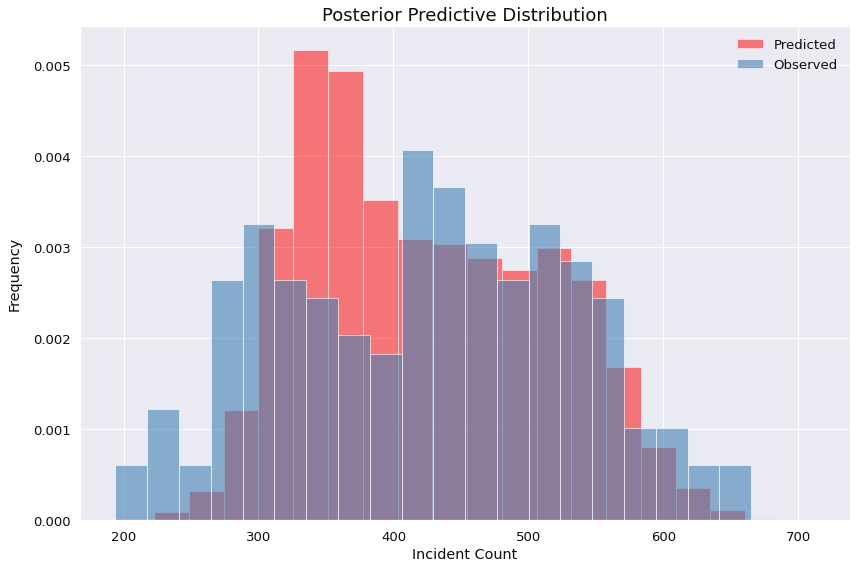

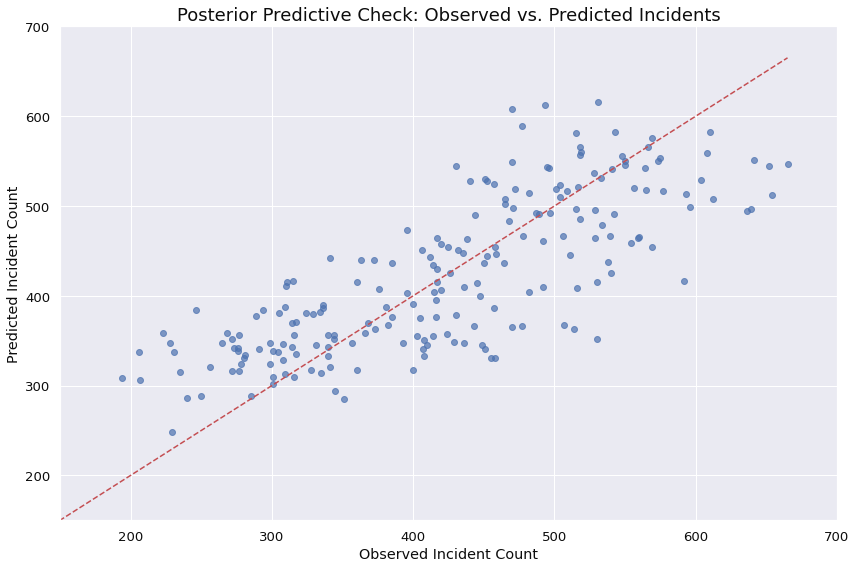

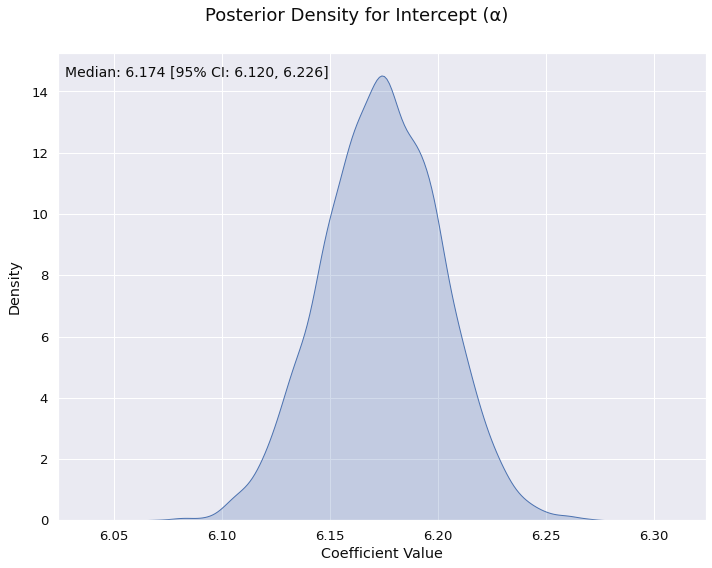

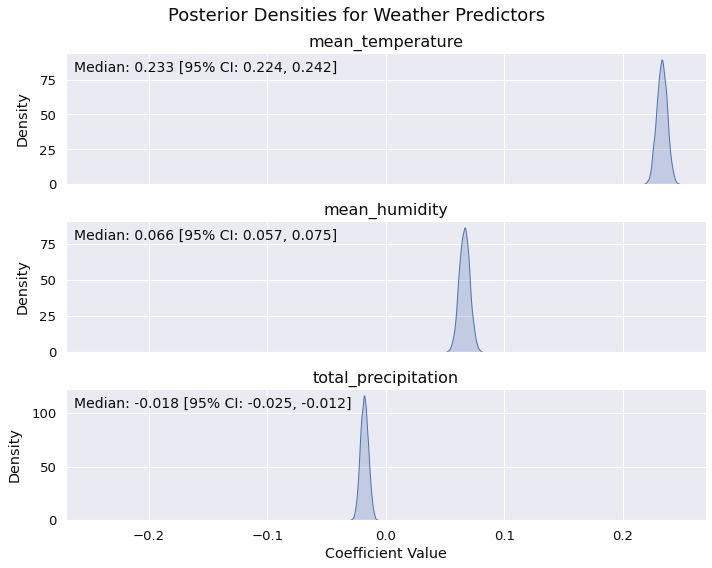

In [11]:
# Posterior Predictive Check
plt.figure(figsize=(12, 8))
plt.hist(y_rep_weather.flatten(), bins=20, alpha=0.5, color='red', label='Predicted', density=True)
plt.hist(df_weekly['incidents'], bins=20, alpha=0.6, color='steelblue', label='Observed', density=True)
plt.title('Posterior Predictive Distribution', fontsize=18)
plt.xlabel('Incident Count')
plt.ylabel('Frequency', labelpad=12)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
if len(y_rep_weather.shape) > 1:
    y_rep_weather = np.mean(y_rep_weather, axis=0)
plt.scatter(df_weekly['incidents'], y_rep_weather, alpha=0.7)
plt.plot([0, df_weekly['incidents'].max()], [0, df_weekly['incidents'].max()], 'r--')
plt.xlabel('Observed Incident Count')
plt.ylabel('Predicted Incident Count')
plt.title('Posterior Predictive Check: Observed vs. Predicted Incidents', fontsize=18)
plt.xlim([150, 700])
plt.ylim([150, 700])
plt.tight_layout()
plt.show()


# Alpha density - same figsize as the stacked beta plots
fig_alpha, ax_alpha = plt.subplots(figsize=(10, 8))
fig_alpha.suptitle('Posterior Density for Intercept (α)', fontsize=18)

sns.kdeplot(alpha_post_weather, fill=True, ax=ax_alpha)
ax_alpha.set_title('')
ax_alpha.set_xlabel('Coefficient Value')
ax_alpha.set_ylabel('Density', labelpad=10)

# Add median and 95% CI annotation for alpha
median_alpha = np.median(alpha_post_weather)
ci_lower_alpha = np.percentile(alpha_post_weather, 2.5)
ci_upper_alpha = np.percentile(alpha_post_weather, 97.5)
ax_alpha.annotate(f'Median: {median_alpha:.3f} [95% CI: {ci_lower_alpha:.3f}, {ci_upper_alpha:.3f}]', 
                 xy=(0.012, 0.95), xycoords='axes fraction', fontsize=14)

plt.xlim(median_alpha - 0.15, median_alpha + 0.15) 
plt.tight_layout()
fig_alpha.subplots_adjust(top=0.9)  # Make room for the suptitle
plt.show()


# Beta densities - create two stacked plots (first 3 and last 3)
# First figure - first three predictors
fig1, axes1 = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig1.suptitle('Posterior Densities for Weather Predictors', fontsize=18)

for i in range(3):
    predictor = predictors_weather[i]
    sns.kdeplot(beta_post_weather[:, i], fill=True, ax=axes1[i])
    axes1[i].set_title(f'{predictor}', fontsize=16)
    axes1[i].set_xlim(-0.27, 0.27)
    axes1[i].set_ylabel('Density', labelpad=10)
    
    # Add median and 95% CI annotation
    median = np.median(beta_post_weather[:, i])
    ci_lower = np.percentile(beta_post_weather[:, i], 2.5)
    ci_upper = np.percentile(beta_post_weather[:, i], 97.5)
    axes1[i].annotate(f'Median: {median:.3f} [95% CI: {ci_lower:.3f}, {ci_upper:.3f}]', 
                     xy=(0.012, 0.86), xycoords='axes fraction' , fontsize=14)

# Only set xlabel for the bottom plot
axes1[-1].set_xlabel('Coefficient Value')
plt.tight_layout()
fig1.subplots_adjust(top=0.9)  # Make room for the suptitle
plt.show()

# Model 2: Socioeconomic + Weather Factors
Define the comprehensive model using both socioeconomic and weather predictors. Prepare data for Stan with appropriate priors.

In [12]:
# Model 2: Socioeconomic + Weather Factors

# Prepare the data structure for Stan
predictors_socio_weather = predictors_weather +['population_density', 'passenger_cars', 'road_density']
X_socio_weather = df_weekly[predictors_socio_weather].values

# Define Stan data
stan_data_socio_weather = {
    'N': len(df_weekly),
    'K': len(predictors_socio_weather),
    'X': X_socio_weather,
    'y': df_weekly['incidents'].values,
    'alpha_mean': 3.0,        # Prior for intercept, exp(3) ≈ 20 weekly incidents
    'alpha_sd': 0.3,          # Reasonable variation for weekly data
    'beta_sd': 0.2,           # Prior for coefficients
    'max_log_lambda': 6.7     # log(1800) ≈ 7.5, caps lambda at ~1800 weekly incidents
}

# Display the prepared data dimensions
print(f"Number of observations (N): {stan_data_socio_weather['N']}")
print(f"Number of predictors (K): {stan_data_socio_weather['K']}")

Number of observations (N): 209
Number of predictors (K): 6


# Prior Analysis for Model 2
Sample from prior distributions for the comprehensive model. Create separate figures for each coefficient and intercept prior distribution, removing legends.

In [13]:
# Prior Analysis for Model 2

# Compile the prior model
prior_model_socio_weather = CmdStanModel(stan_file="models/socioeconomic_prior.stan")

# Sample from prior
prior_fit_socio_weather = prior_model_socio_weather.sample(
    data=stan_data_socio_weather,
    iter_sampling=2000,
    iter_warmup=500,
    chains=4,
    fixed_param=True,
    seed=42,
    output_dir='./models_outputs'
)

# Extract prior samples
alpha_prior_socio_weather = prior_fit_socio_weather.stan_variable("alpha")
beta_prior_socio_weather = prior_fit_socio_weather.stan_variable("beta")
y_prior_socio_weather = prior_fit_socio_weather.stan_variable("y_prior")

INFO:cmdstanpy:found newer exe file, not recompiling
INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▋         | 00:00 Iteration:    1 / 2000 [  0%]  (Sampling)




chain 1 |██▏       | 00:00 Iteration:  400 / 2000 [ 20%]  (Sampling)
chain 1 |███▎      | 00:00 Iteration:  700 / 2000 [ 35%]  (Sampling)


chain 1 |████▍     | 00:00 Iteration: 1000 / 2000 [ 50%]  (Sampling)



chain 1 |█████▌    | 00:00 Iteration: 1300 / 2000 [ 65%]  (Sampling)


chain 1 |███████   | 00:00 Iteration: 1700 / 2000 [ 85%]  (Sampling)

chain 1 |██████████| 00:00 Sampling completed                       
chain 2 |██████████| 00:00 Sampling completed
chain 3 |██████████| 00:00 Sampling completed                       
chain 4 |██████████| 00:00 Sampling completed                       

INFO:cmdstanpy:CmdStan done processing.


<>:33: SyntaxWarning: invalid escape sequence '\_'
<>:33: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_890/584333687.py:33: SyntaxWarning: invalid escape sequence '\_'
  plt.title(f'Prior Distribution of the $\\mathit{{{predictor.replace('_', '\_')}}}$ Coefficient ($\\beta_{{{i+1}}}$)', fontsize=18)


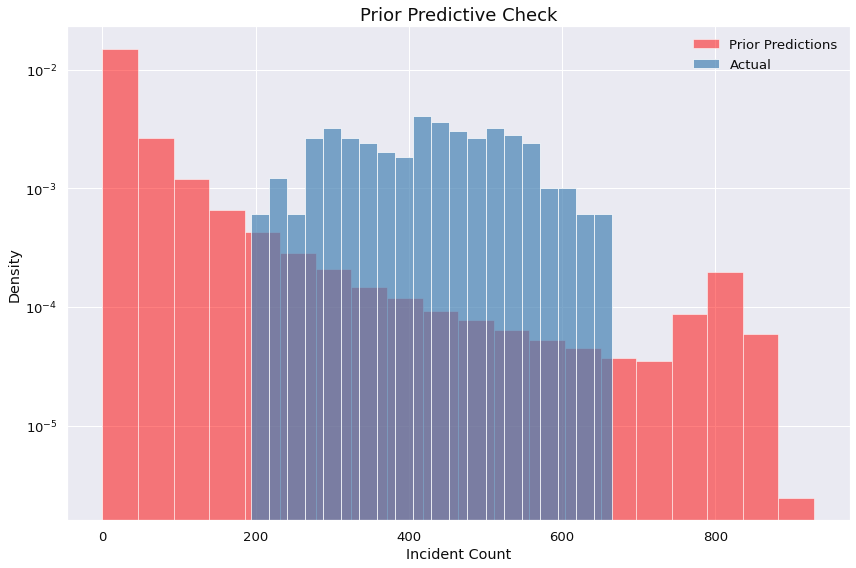

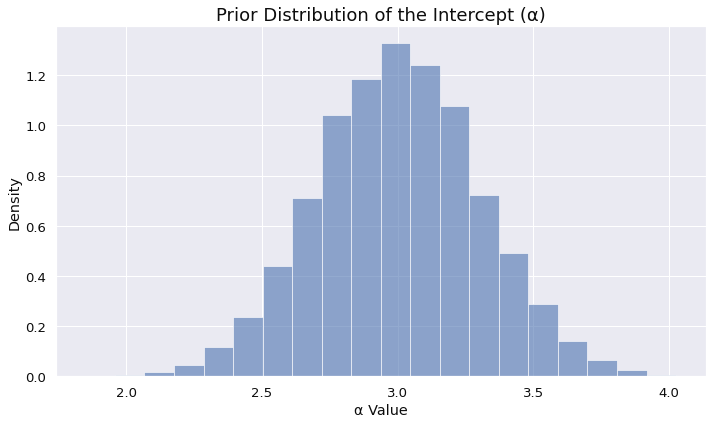

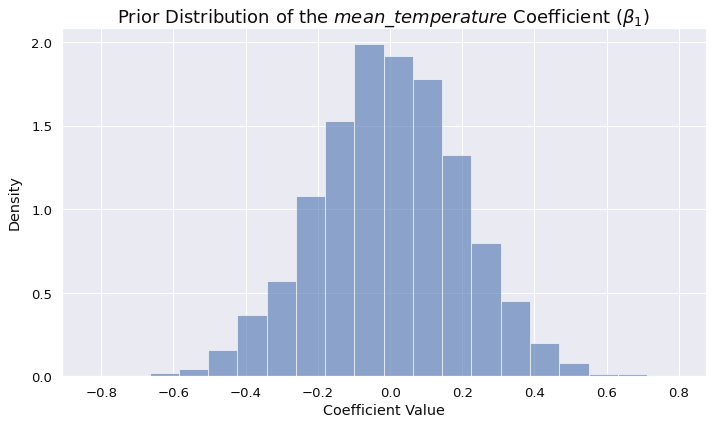

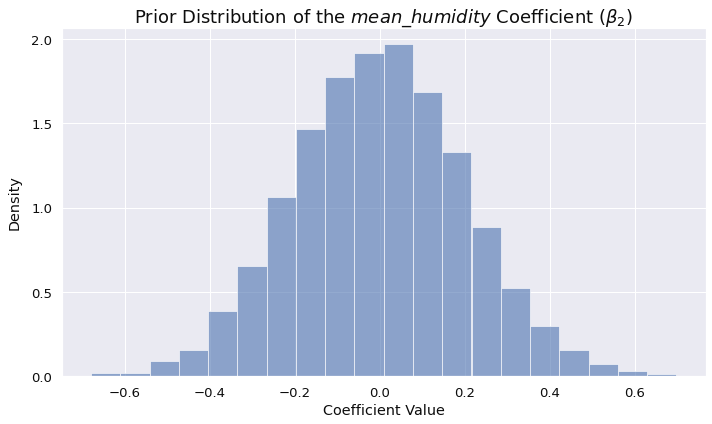

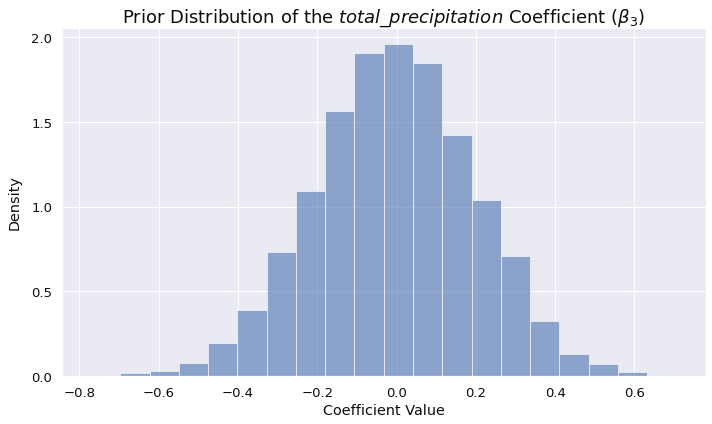

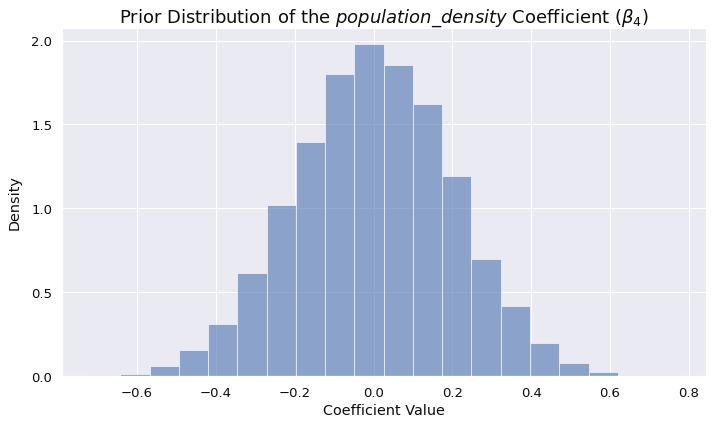

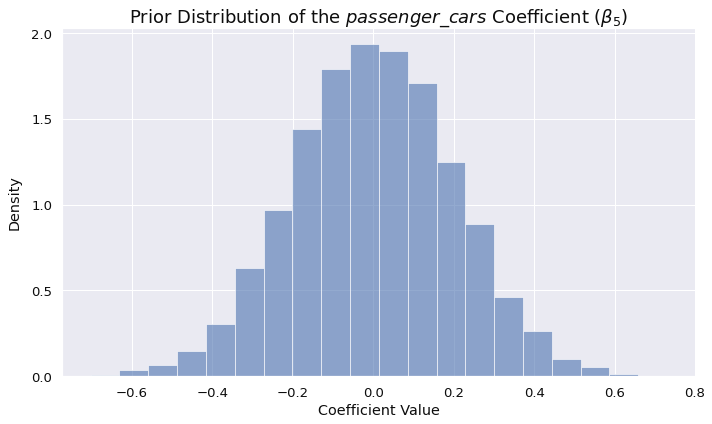

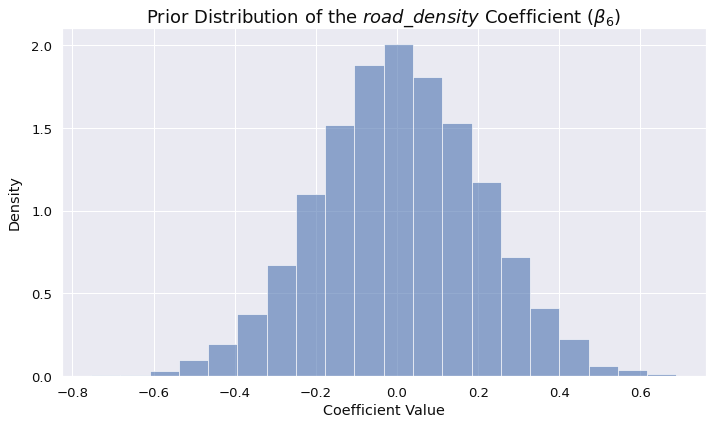

In [14]:
# Import the necessary formatter
from matplotlib.ticker import FormatStrFormatter, MultipleLocator

# Prior Predictive Check
plt.figure(figsize=(12, 8))
y_prior_flat_socio_weather = y_prior_socio_weather.flatten()
valid_indices_socio_weather = ~np.isnan(y_prior_flat_socio_weather)
plt.hist(y_prior_flat_socio_weather[valid_indices_socio_weather], bins=20, alpha=0.5, color='red', label='Prior Predictions', density=True)
plt.hist(df_weekly['incidents'], bins=20, alpha=0.7, color='steelblue', label='Actual', density=True)
plt.yscale('log')
plt.title('Prior Predictive Check', fontsize=18)
plt.xlabel('Incident Count')
plt.ylabel('Density')
# plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # Format to 1 decimal place
plt.legend()
plt.tight_layout()
plt.show()

# Prior distribution of intercept
plt.figure(figsize=(10, 6))
plt.hist(alpha_prior_socio_weather, bins=20, alpha=0.6, density=True)
plt.title('Prior Distribution of the Intercept (α)', fontsize=18)
plt.xlabel('α Value')
plt.ylabel('Density')
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # Format to 1 decimal place
plt.tight_layout()
plt.show()

# Prior distribution of socioeconomic + weather coefficients
for i, predictor in enumerate(predictors_socio_weather):
    plt.figure(figsize=(10, 6))
    plt.hist(beta_prior_socio_weather[:, i], bins=20, alpha=0.6, density=True)
    plt.title(f'Prior Distribution of the $\\mathit{{{predictor.replace('_', '\_')}}}$ Coefficient ($\\beta_{{{i+1}}}$)', fontsize=18)
    plt.xlabel('Coefficient Value')
    plt.ylabel('Density', labelpad=10)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # Format to 1 decimal place
    plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))  # Set minimum tick spacing to 0.5
    plt.tight_layout()
    plt.show()

# Posterior Analysis for Model 2
Fit the comprehensive model using Stan and analyze posterior distributions. Create trace plots as separate figures, and posterior density plots for each coefficient/intercept as separate figures without prior mean references.

In [15]:
# Posterior Analysis for Model 2

# Compile the posterior model
posterior_model_socio_weather = CmdStanModel(stan_file="models/socioeconomic_posterior.stan")

# Sample from the posterior
posterior_fit_socio_weather = posterior_model_socio_weather.sample(
    data=stan_data_socio_weather,
    iter_sampling=2000,
    iter_warmup=500,
    chains=4,
    seed=42,
    output_dir='./models_outputs'
)

# Extract posterior samples
alpha_post_socio_weather = posterior_fit_socio_weather.stan_variable("alpha")
beta_post_socio_weather = posterior_fit_socio_weather.stan_variable("beta")
y_rep_socio_weather = posterior_fit_socio_weather.stan_variable("y_rep")

INFO:cmdstanpy:found newer exe file, not recompiling
INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |█▍        | 00:00 Iteration:  200 / 2500 [  8%]  (Warmup)




chain 1 |██▏       | 00:00 Iteration:  400 / 2500 [ 16%]  (Warmup)






chain 1 |██▉       | 00:01 Iteration:  501 / 2500 [ 20%]  (Sampling)





chain 1 |███▎      | 00:01 Iteration:  600 / 2500 [ 24%]  (Sampling)


chain 1 |███▋      | 00:02 Iteration:  700 / 2500 [ 28%]  (Sampling)





chain 1 |████      | 00:02 Iteration:  800 / 2500 [ 32%]  (Sampling)


chain 1 |████▍     | 00:03 Iteration:  900 / 2500 [ 36%]  (Sampling)



chain 1 |████▊     | 00:03 Iteration: 1000 / 2500 [ 40%]  (Sampling)





chain 1 |█████▏    | 00:04 Iteration: 1100 / 2500 [ 44%]  (Sampling)




chain 1 |█████▌    | 00:04 Iteration: 1200 / 2500 [ 48%]  (Sampling)


chain 1 |█████▉    | 00:05 Iteration: 1300 / 2500 [ 52%]  (Sampling)





chain 1 |██████▎   | 00:06 Iteration: 1400 / 2500 [ 56%]  (Sampling)



c


INFO:cmdstanpy:CmdStan done processing.


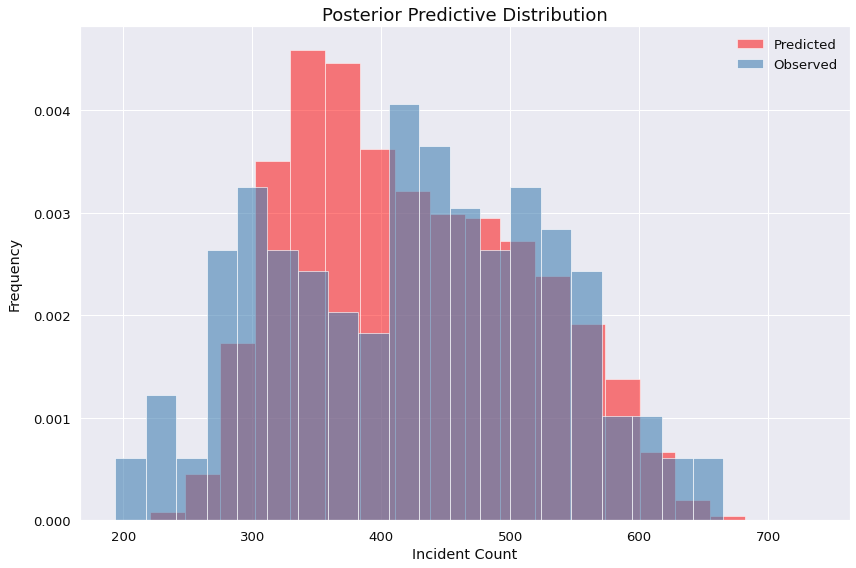

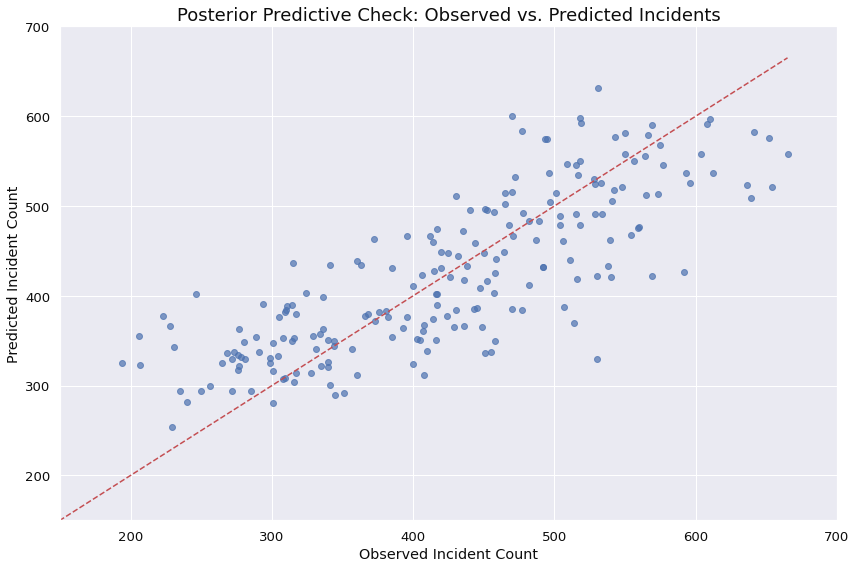

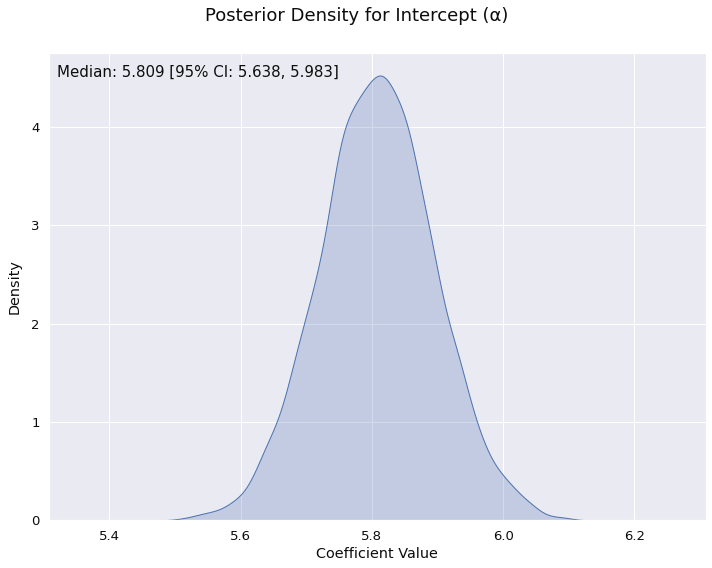

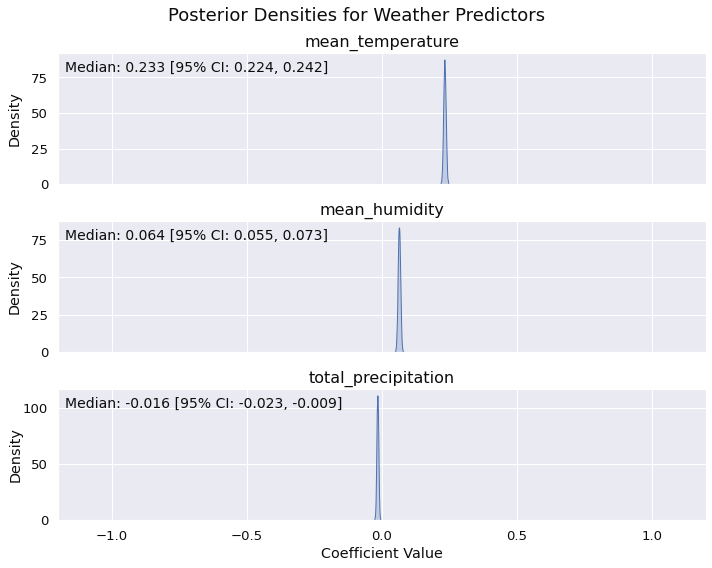

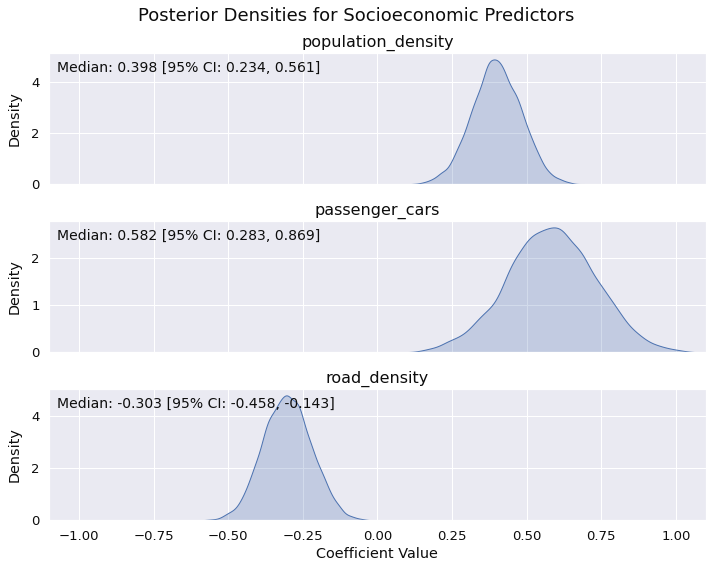

In [16]:
# Posterior Predictive Check
plt.figure(figsize=(12, 8))
plt.hist(y_rep_socio_weather.flatten(), bins=20, alpha=0.5, color='red', label='Predicted', density=True)
plt.hist(df_weekly['incidents'], bins=20, alpha=0.6, color='steelblue', label='Observed', density=True)
plt.title('Posterior Predictive Distribution', fontsize=18)
plt.xlabel('Incident Count')
plt.ylabel('Frequency', labelpad=12)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
if len(y_rep_socio_weather.shape) > 1:
    y_rep_socio_weather = np.mean(y_rep_socio_weather, axis=0)
plt.scatter(df_weekly['incidents'], y_rep_socio_weather, alpha=0.7)
plt.plot([0, df_weekly['incidents'].max()], [0, df_weekly['incidents'].max()], 'r--')
plt.xlabel('Observed Incident Count')
plt.ylabel('Predicted Incident Count')
plt.title('Posterior Predictive Check: Observed vs. Predicted Incidents', fontsize=18)
plt.xlim([150, 700])
plt.ylim([150, 700])
plt.tight_layout()
plt.show()


# Alpha density - same figsize as the stacked beta plots
fig_alpha, ax_alpha = plt.subplots(figsize=(10, 8))
fig_alpha.suptitle('Posterior Density for Intercept (α)', fontsize=18)

sns.kdeplot(alpha_post_socio_weather, fill=True, ax=ax_alpha)
ax_alpha.set_title('')
ax_alpha.set_xlabel('Coefficient Value')
ax_alpha.set_ylabel('Density', labelpad=10)

# Add median and 95% CI annotation for alpha
median_alpha = np.median(alpha_post_socio_weather)
ci_lower_alpha = np.percentile(alpha_post_socio_weather, 2.5)
ci_upper_alpha = np.percentile(alpha_post_socio_weather, 97.5)
ax_alpha.annotate(f'Median: {median_alpha:.3f} [95% CI: {ci_lower_alpha:.3f}, {ci_upper_alpha:.3f}]', 
                 xy=(0.012, 0.95), xycoords='axes fraction', fontsize=15)

plt.xlim(median_alpha - 0.5, median_alpha + 0.5) 
plt.tight_layout()
fig_alpha.subplots_adjust(top=0.9)  # Make room for the suptitle
plt.show()


# Beta densities - create two stacked plots (first 3 and last 3)
# First figure - first three predictors
fig1, axes1 = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig1.suptitle('Posterior Densities for Weather Predictors', fontsize=18)

for i in range(3):
    predictor = predictors_socio_weather[i]
    sns.kdeplot(beta_post_socio_weather[:, i], fill=True, ax=axes1[i])
    axes1[i].set_title(f'{predictor}', fontsize=16)
    axes1[i].set_xlim(-1.2, 1.2)
    axes1[i].set_ylabel('Density', labelpad=10)
    
    # Add median and 95% CI annotation
    median = np.median(beta_post_socio_weather[:, i])
    ci_lower = np.percentile(beta_post_socio_weather[:, i], 2.5)
    ci_upper = np.percentile(beta_post_socio_weather[:, i], 97.5)
    axes1[i].annotate(f'Median: {median:.3f} [95% CI: {ci_lower:.3f}, {ci_upper:.3f}]', 
                     xy=(0.012, 0.86), xycoords='axes fraction', fontsize=14)

# Only set xlabel for the bottom plot
axes1[i].set_ylabel('Density', labelpad=0)
axes1[-1].set_xlabel('Coefficient Value')
plt.tight_layout()
fig1.subplots_adjust(top=0.9)  # Make room for the suptitle
plt.show()

# Second figure - last three predictors
fig2, axes2 = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig2.suptitle('Posterior Densities for Socioeconomic Predictors', fontsize=18)
for i in range(3):
    idx = i + 3
    predictor = predictors_socio_weather[idx]
    sns.kdeplot(beta_post_socio_weather[:, idx], fill=True, ax=axes2[i])
    axes2[i].set_title(f'{predictor}', fontsize=16)
    axes2[i].set_xlim(-1.1, 1.1)
    axes2[i].set_ylabel('Density', labelpad=10)
    
    # Add median and 95% CI annotation
    median = np.median(beta_post_socio_weather[:, idx])
    ci_lower = np.percentile(beta_post_socio_weather[:, idx], 2.5)
    ci_upper = np.percentile(beta_post_socio_weather[:, idx], 97.5)
    axes2[i].annotate(f'Median: {median:.3f} [95% CI: {ci_lower:.3f}, {ci_upper:.3f}]', 
                     xy=(0.012, 0.86), xycoords='axes fraction', fontsize=14)

axes2[i].set_ylabel('Density', labelpad=10)
axes2[-1].set_xlabel('Coefficient Value')

plt.tight_layout()
fig2.subplots_adjust(top=0.9)  # Make room for the suptitle
plt.show()

# Model Comparison
Compare the two models using appropriate metrics such as WAIC, LOO-CV. Create visualizations to show prediction accuracy and residuals.

/usr/local/lib/python3.12/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.12/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influent

WAIC for Weather Factors Only Model: Computed from 8000 posterior samples and 209 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -2019.21   105.12
p_waic       51.29        -

There has been a warning during the calculation. Please check the results.
WAIC for Socioeconomic + Weather Factors Model: Computed from 8000 posterior samples and 209 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1941.50   115.10
p_waic       72.26        -

There has been a warning during the calculation. Please check the results.

LOO-CV for Weather Factors Only Model: Computed from 8000 posterior samples and 209 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2019.78   105.23
p_loo       51.86        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      207   99.0%
   (0.70, 1]   (bad)         2    1.0%


/usr/local/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(



Model Comparison using the PSIS-LOO criterion:
         rank     elpd_loo      p_loo  elpd_diff    weight          se  \
Model 4     0 -1941.622555  72.381663   0.000000  0.639492  115.112377   
Model 3     1 -2019.775030  51.860091  78.152475  0.360508  105.225669   

               dse  warning scale  
Model 4   0.000000     True   log  
Model 3  43.199984     True   log  


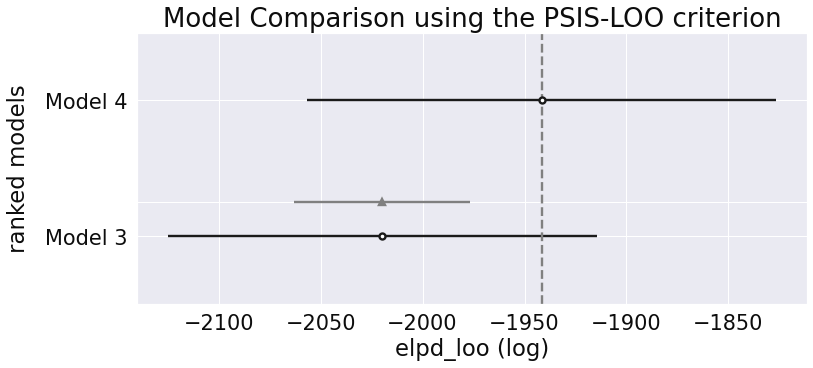

Model Comparison Summary:
         rank     elpd_loo      p_loo  elpd_diff    weight          se  \
Model 4     0 -1941.622555  72.381663   0.000000  0.639492  115.112377   
Model 3     1 -2019.775030  51.860091  78.152475  0.360508  105.225669   

               dse  warning scale  
Model 4   0.000000     True   log  
Model 3  43.199984     True   log  


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Model 4,0,-1941.622555,72.381663,0.000000,0.639492,115.112377,0.000000,True,log
Model 3,1,-2019.775030,51.860091,78.152475,0.360508,105.225669,43.199984,True,log


In [17]:
# Model Comparison

# Calculate WAIC for each model
waic_weather = az.waic(posterior_fit_weather)
waic_socio_weather = az.waic(posterior_fit_socio_weather)

# Calculate LOO-CV for each model
loo_weather = az.loo(posterior_fit_weather)
loo_socio_weather = az.loo(posterior_fit_socio_weather)

# Print WAIC and LOO-CV results
print("WAIC for Weather Factors Only Model:", waic_weather)
print("WAIC for Socioeconomic + Weather Factors Model:", waic_socio_weather)

print("\nLOO-CV for Weather Factors Only Model:", loo_weather)
print("LOO-CV for Socioeconomic + Weather Factors Model:", loo_socio_weather)

# Compare models using WAIC and LOO-CV
model_comparison = az.compare({
    "Model 3": posterior_fit_weather,
    "Model 4": posterior_fit_socio_weather
}, ic='loo')

# Display model comparison
print("\nModel Comparison using the PSIS-LOO criterion:")
print(model_comparison)

# Visualize model comparison
az.plot_compare(model_comparison, figsize=(12, 5), plot_ic_diff=True)   
plt.title('Model Comparison using the PSIS-LOO criterion', fontdict={'fontsize': 26})
plt.ylabel('ranked models', labelpad=15)
plt.show()

# Summary of model comparison
print("Model Comparison Summary:")
print(model_comparison)
model_comparison
# Visualize prediction accuracy and residuals for each model

# # Function to plot observed vs predicted incidents
# def plot_observed_vs_predicted(y_obs, y_pred, title):
#     plt.figure(figsize=(12, 8))
#     plt.scatter(y_obs, y_pred, alpha=0.7)
#     plt.plot([0, max(y_obs)], [0, max(y_obs)], 'r--')
#     plt.xlabel('Observed Incident Count')
#     plt.ylabel('Predicted Incident Count')
#     plt.title(title)
#     plt.tight_layout()
#     plt.show()

# # Plot observed vs predicted for each model
# plot_observed_vs_predicted(df_weekly['incidents'], y_rep_weather, 'Observed vs. Predicted Incidents (Socioeconomic Factors Only)')
# plot_observed_vs_predicted(df_weekly['incidents'], y_rep_socio_weather, 'Observed vs. Predicted Incidents (Socioeconomic + Weather Factors)')

# # Function to plot residuals
# def plot_residuals(y_obs, y_pred, title):
#     residuals = y_obs - y_pred
#     plt.figure(figsize=(12, 8))
#     plt.scatter(y_obs, residuals, alpha=0.7)
#     plt.axhline(y=0, color='r', linestyle='--')
#     plt.xlabel('Observed Incident Count')
#     plt.ylabel('Residuals')
#     plt.title(title)
#     plt.tight_layout()
#     plt.show()

# # Plot residuals for each model
# plot_residuals(df_weekly['incidents'], y_rep_weather, 'Residuals (Socioeconomic Factors Only)')
# plot_residuals(df_weekly['incidents'], y_rep_socio_weather, 'Residuals (Socioeconomic + Weather Factors)')

In [18]:
model_comparison.to_dict()

{'rank': {'Model 4': 0, 'Model 3': 1},
 'elpd_loo': {'Model 4': -1941.6225549851088, 'Model 3': -2019.7750302068164},
 'p_loo': {'Model 4': 72.38166258147521, 'Model 3': 51.86009077618087},
 'elpd_diff': {'Model 4': 0.0, 'Model 3': 78.1524752217075},
 'weight': {'Model 4': 0.6394921733866071, 'Model 3': 0.36050782661339287},
 'se': {'Model 4': 115.11237665127501, 'Model 3': 105.22566874622493},
 'dse': {'Model 4': 0.0, 'Model 3': 43.19998398443434},
 'warning': {'Model 4': True, 'Model 3': True},
 'scale': {'Model 4': 'log', 'Model 3': 'log'}}

# Results Interpretation
Interpret the results, discussing which factors are most important for predicting weekly traffic incidents. Analyze implications for traffic safety.

/tmp/ipykernel_890/1343716962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_weekly['predicted_incidents_weather'] = y_rep_weather
/tmp/ipykernel_890/1343716962.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_weekly['predicted_incidents_socio_weather'] = y_rep_socio_weather
/tmp/ipykernel_890/1343716962.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

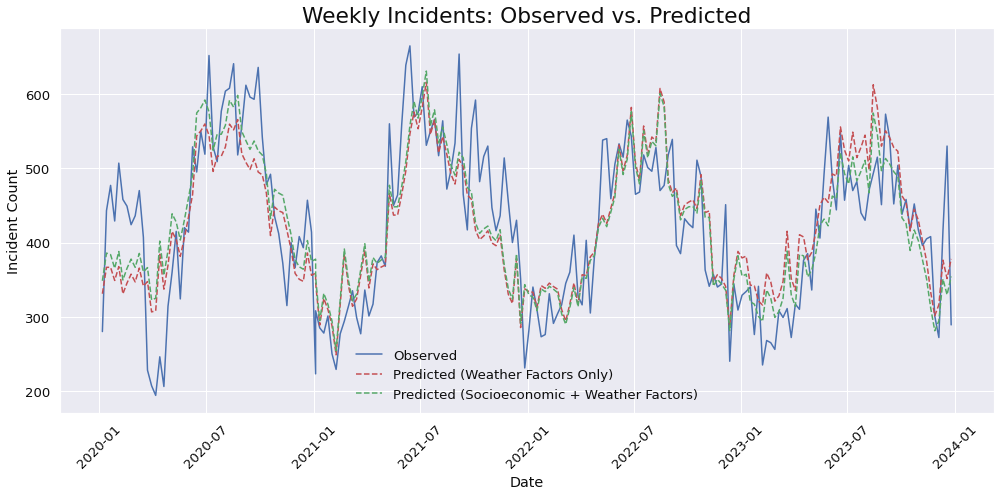

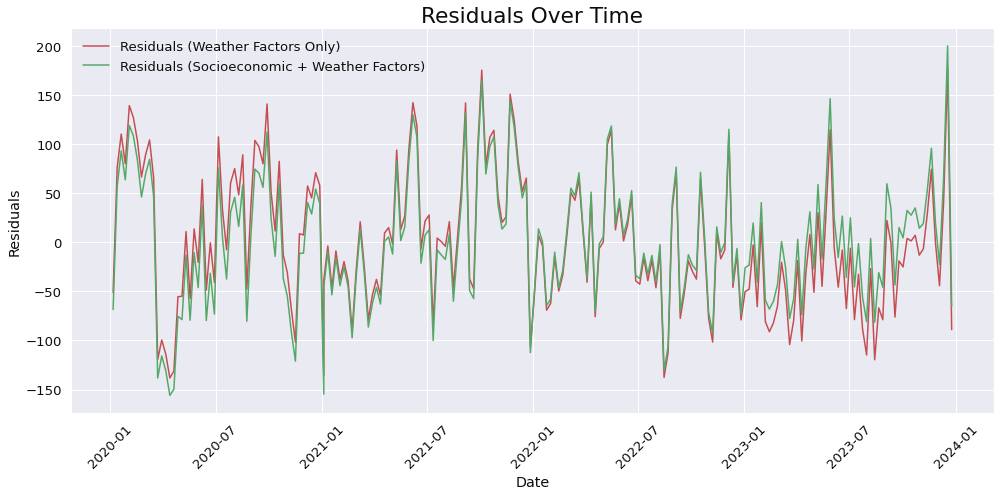

In [19]:
# Results Interpretation

# Add predictions to the dataset for each model
df_weekly['predicted_incidents_weather'] = y_rep_weather
df_weekly['predicted_incidents_socio_weather'] = y_rep_socio_weather

# Calculate residuals for each model
df_weekly['residuals_weather'] = df_weekly['incidents'] - df_weekly['predicted_incidents_weather']
df_weekly['residuals_socio_weather'] = df_weekly['incidents'] - df_weekly['predicted_incidents_socio_weather']

# Plot time series of observed vs. predicted incidents for each model
plt.figure(figsize=(14, 7))
plt.plot(df_weekly['date'], df_weekly['incidents'], 'b-', label='Observed')
plt.plot(df_weekly['date'], df_weekly['predicted_incidents_weather'], 'r--', label='Predicted (Weather Factors Only)')
plt.plot(df_weekly['date'], df_weekly['predicted_incidents_socio_weather'], 'g--', label='Predicted (Socioeconomic + Weather Factors)')
plt.title('Weekly Incidents: Observed vs. Predicted')
plt.xlabel('Date')
plt.ylabel('Incident Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot residuals over time for each model
plt.figure(figsize=(14, 7))
plt.plot(df_weekly['date'], df_weekly['residuals_weather'], 'r-', label='Residuals (Weather Factors Only)')
plt.plot(df_weekly['date'], df_weekly['residuals_socio_weather'], 'g-', label='Residuals (Socioeconomic + Weather Factors)')
plt.title('Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()